# EKF VS KALMAN FILTER

In the most basic sense, EKF is a generalised version of the kalman filter. When we assume a linear relationshop in EKF, it acts the same as a Kalman Filter.


In [48]:
import os, glob
import numpy as np
import pandas as pd
import backtrader as bt
import matplotlib.pyplot as plt

from KalmanFilter import KalmanTest
from ExtendedKalmanFilter import ExtendedKalmanTest

## Over-Arching Setup

Basic setup for either type of kalman filter.

In [49]:
def estimatefuture(X, P, Q, f_func,F_jac, **kwargs):
    Xfuture = f_func(X, **kwargs)
    F = F_jac(X, **kwargs)
    Pfuture = F @ P @ np.transpose(F) + Q
    Pfuture = 0.5 * (Pfuture + Pfuture.T)      # force symmetry
    return Xfuture, Pfuture


def KalmanGain(Pold, R, H_jac, X_pred):
    H = H_jac(X_pred)
    K = Pold @ np.transpose(H) @ np.linalg.inv(H @ Pold @ np.transpose(H) + R)
    return K, H


def consolidatecurrent(Xold, Pold, K, Z, H, h_func):
    X = Xold + K @ (Z - h_func(Xold))
    P = (np.identity(np.shape(H)[1]) - K @ H) @ Pold
    P = 0.5 * (P + P.T)      # force symmetry
    return X, P

## Standard Kalman Filter

Basically here in the estimation step, we just have to apply a transformation matrix since it is linear. It is chartacterized by the fact that, the jacobian of the function is the transformation matrix itself.

In [50]:
def f_func(Xf):
    return np.array([[1.0, 1.0, 0.5],
                    [0.0, 1.0, 1.0],
                    [0.0, 0.0, 1.0]])@ Xf 

def h_func(X):
    return np.array([[1.0, 0.0, 0.0]]) @ X

def F_jac(X):
    return np.array([[1.0, 1.0, 0.5], [0.0, 1.0, 1.0], [0.0, 0.0, 1.0]])

def H_jac(X):
    return np.array([[1.0, 0.0, 0.0]])

## EKF

Here our prediction function isn't linenar and so we cannot describe it in terms of a pure linear matrix. Thus we need to recalculate the jacobian after every iteration.


In [51]:

def f_func(Xf, drag, price):
    velocity = Xf[1, 0]
    F_lin = np.array([[1.0, 1.0, 0.5],
                    [0.0, 1.0, 1.0],
                    [0.0, 0.0, 1.0]])
    drag_accel = drag * velocity * np.abs(velocity) / price
    drag_term = np.array([[0.0],
                        [0.0],
                        [drag_accel]])
    return F_lin @ Xf - drag_term

def h_func(X):
    return np.array([[1.0, 0.0, 0.0]]) @ X

def F_jac(X, drag, price):
    vel = X[1, 0]
    return np.array([[1.0, 1.0, 0.5],
                    [0.0, 1.0, 1.0],
                    [0.0, -2*drag*abs(vel)/price, 1.0  ]])

def H_jac(X):
    return np.array([[1.0, 0.0, 0.0]])

## Live strategy comparison — KF vs EKF (real backtest)

The cells above re-implement the filter maths for intuition. Below we run the **actual built strategies**
(`KalmanTest`, `ExtendedKalmanTest`) on one symbol through backtrader with `diag=True`, so each records its
per-bar internals: the prediction, the ±kσ bands, the innovation and its variance `S`, the state `X`,
and **every entry of the covariance matrix `P`** — which the plots below use over the full loaded window.

In [52]:

DATA_DIR = 'datas'
START_CASH, COMMISSION, LEVERAGE = 100_000.0, 0.0002, 10.0

def pick_symbol(prefer='BTCUSDT'):
    paths = sorted(glob.glob(os.path.join(DATA_DIR, '*-1m.csv')))
    hit = [p for p in paths if os.path.basename(p).startswith(prefer + '-1m')]
    path = hit[0] if hit else paths[0]
    return os.path.basename(path)[:-len('-1m.csv')], path

def run_strategy(Strat, params, path, sym):
    cer = bt.Cerebro()
    cer.broker.setcash(START_CASH)
    cer.broker.setcommission(commission=COMMISSION, leverage=LEVERAGE)
    cer.adddata(bt.feeds.GenericCSVData(
        dataname=path, dtformat='%Y-%m-%d %H:%M:%S',
        timeframe=bt.TimeFrame.Minutes, compression=1,
        datetime=0, open=1, high=2, low=3, close=4, volume=5,
        openinterest=-1, name=sym))
    cer.addstrategy(Strat, **dict(params, diag=True))
    strat = cer.run()[0]
    end = cer.broker.getvalue()

    diag = pd.DataFrame(strat._diag[sym])
    diag['dt'] = pd.to_datetime(diag['t'], unit='s', utc=True)
    diag = diag.set_index('dt')

    eq = pd.DataFrame(strat.equity, columns=['dt', 'value'])
    eq['dt'] = pd.to_datetime(eq['dt'])
    eq = eq.set_index('dt')

    tl = strat.trade_log
    wins = sum(1 for t in tl if t['pnlcomm'] > 0)
    stats = dict(end_value=round(end, 2), pnl=round(end - START_CASH, 2),
                 trades=len(tl), wins=wins,
                 win_rate=round(100.0 * wins / len(tl), 2) if tl else 0.0)
    return dict(name=Strat.__name__, diag=diag, equity=eq, stats=stats, strat=strat)

SYMBOL, PATH = pick_symbol('ETHUSDT')
print('Using symbol:', SYMBOL)

Using symbol: ETHUSDT


In [53]:
KF_PARAMS  = dict(k=2, warmup=180, q_level=0.1e-3, q_vel=0.1e-6)
EKF_PARAMS = dict(k=2, warmup=180, q_level=0.1e-3, q_vel=0.1e-6,
                  k_exit=0.0, min_hold=1, cost_mult=0.0, drag_m=0.001,
                  trend_bias=False, c_d_window=180)

kf  = run_strategy(KalmanTest, KF_PARAMS, PATH, SYMBOL)
ekf = run_strategy(ExtendedKalmanTest, EKF_PARAMS, PATH, SYMBOL)

summary = pd.DataFrame([kf['stats'], ekf['stats']], index=[kf['name'], ekf['name']])
summary

2026-07-13T09:57:59, (k=2 warmup=180) Ending Value 98530.19
2026-07-13T09:57:59, (k=2 warmup=180) Ending Value 99446.80


,end_value,pnl,trades,wins,win_rate
KalmanTest,98530.19,-1469.81,587,327,55.71
ExtendedKalmanTest,99446.80,-553.20,429,236,55.01


### Prediction line & confidence bands

The Kalman prediction (fair-value estimate) with the ±kσ band the strategy trades against, over the
last day of bars for legibility.

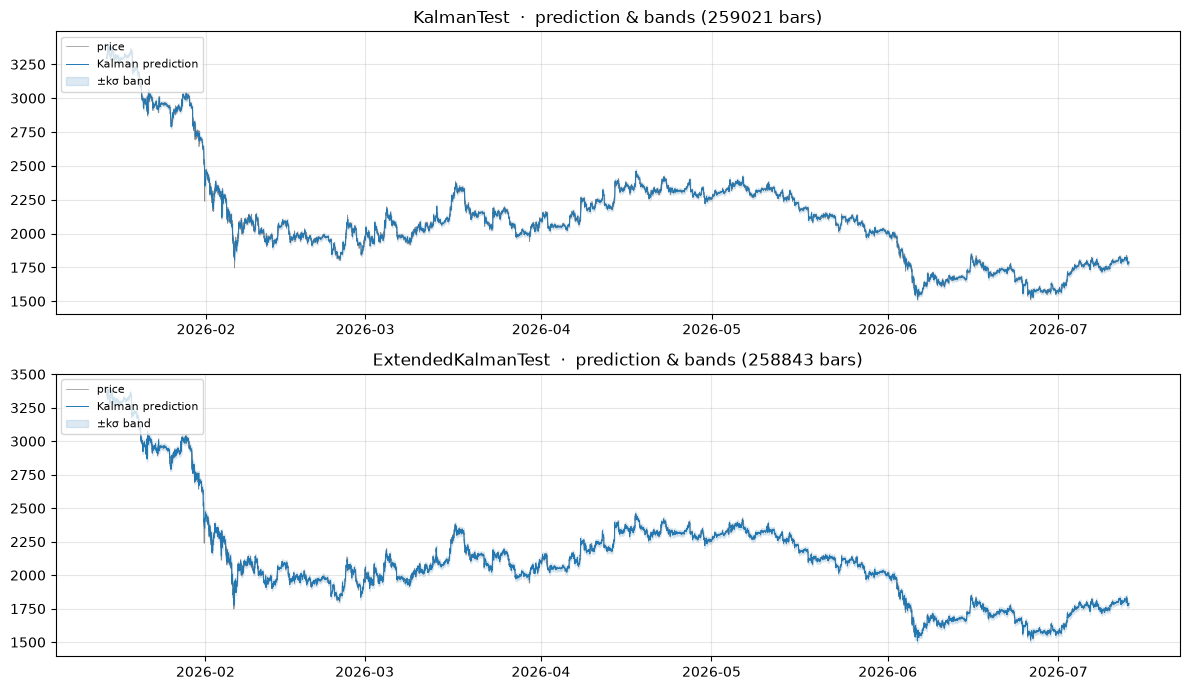

In [54]:
def plot_pred(res, ax, zoom=None):
    # zoom=None -> the FULL loaded window (all 180 days); set an int for a
    # last-N-bars close-up (e.g. zoom=1440 for one day).
    d = res['diag'] if zoom is None else res['diag'].iloc[-zoom:]
    ax.plot(d.index, d['price'], color='#8a8a8a', lw=0.5, label='price')
    ax.plot(d.index, d['pred'],  color='#1f77b4', lw=0.7, label='Kalman prediction')
    ax.fill_between(d.index, d['lower'], d['upper'], color='#1f77b4', alpha=0.15,
                    label='±kσ band')
    ax.set_title('%s  ·  prediction & bands (%d bars)' % (res['name'], len(d)))
    ax.legend(loc='upper left', fontsize=8); ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_pred(kf, axes[0]); plot_pred(ekf, axes[1])   # full history; pass zoom=1440 to zoom in
plt.tight_layout(); plt.show()

### Innovation and its uncertainty

The **innovation** is price − prediction (what surprised the filter each bar). Its **uncertainty** is
`√S`, the standard deviation of that innovation — the band is exactly `k·√S`, so this is what sets how far
price must stray before a trade fires.

INNOV rms ( KalmanTest ):  0.0031333458756389095
INNOV rms ( ExtendedKalmanTest ):  0.011732197354441769


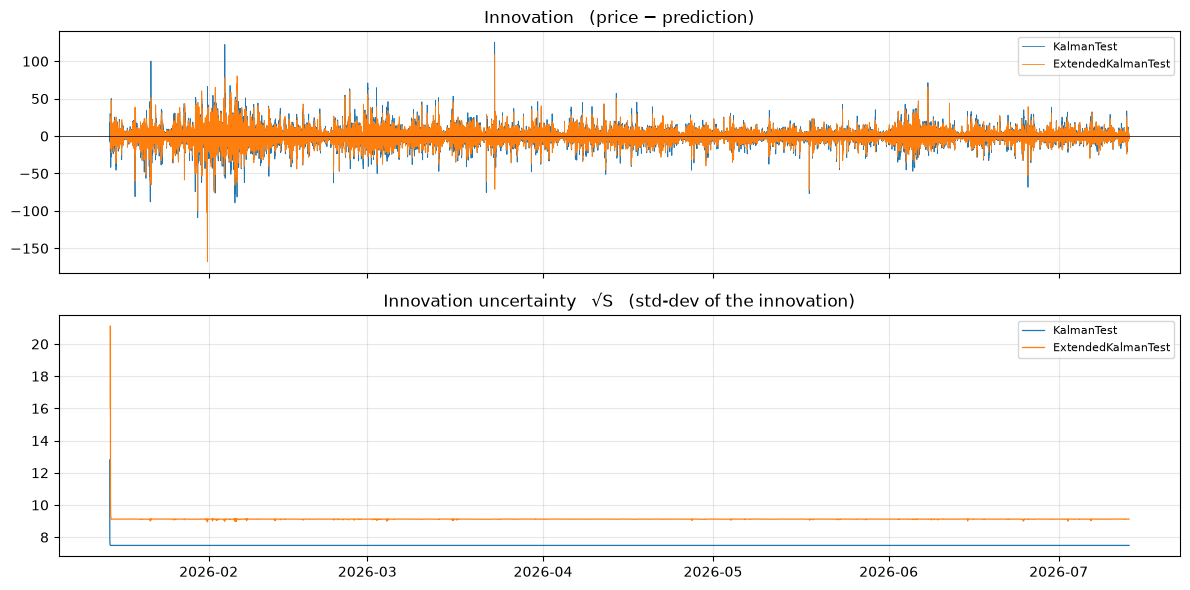

In [55]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for res in (kf, ekf):
    d = res['diag']
    innov = d['innov'].to_numpy(float)
    S = d['S'].to_numpy(float)
    rms = np.sqrt(np.mean(innov ** 2))                  # RMS of the raw innovation
    nis = np.sqrt(np.mean((innov / np.sqrt(S)) ** 2))   # innov/âS: ~1 if S is calibrated
    print("%-20s innovation RMS = %.4g   normalised RMS = %.3g" % (res['name'], rms, nis))
    axes[0].plot(d.index, d['innov'], lw=0.6, label='%s (RMS %.4g)' % (res['name'], rms))
    axes[1].plot(d.index, np.sqrt(d['S']), lw=0.9, label=res['name'])
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('Innovation   (price â prediction)')
axes[1].set_title('Innovation uncertainty   âS')
for a in axes:
    a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Covariance matrix P — every variance & covariance term

Diagonal entries are the **variances** of each state estimate (how unsure the filter is about position /
velocity / acceleration); off-diagonal entries are the **covariances** between states. Each gets its own
panel. Watch them settle after warmup as the filter gains confidence.

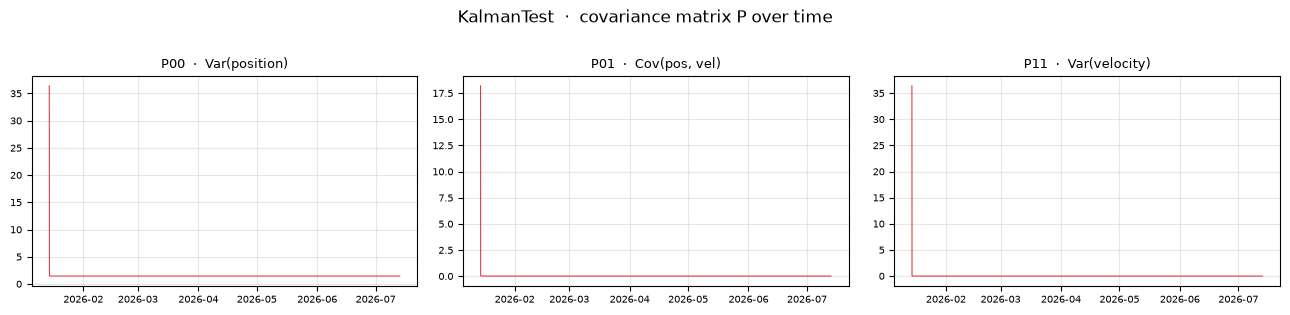

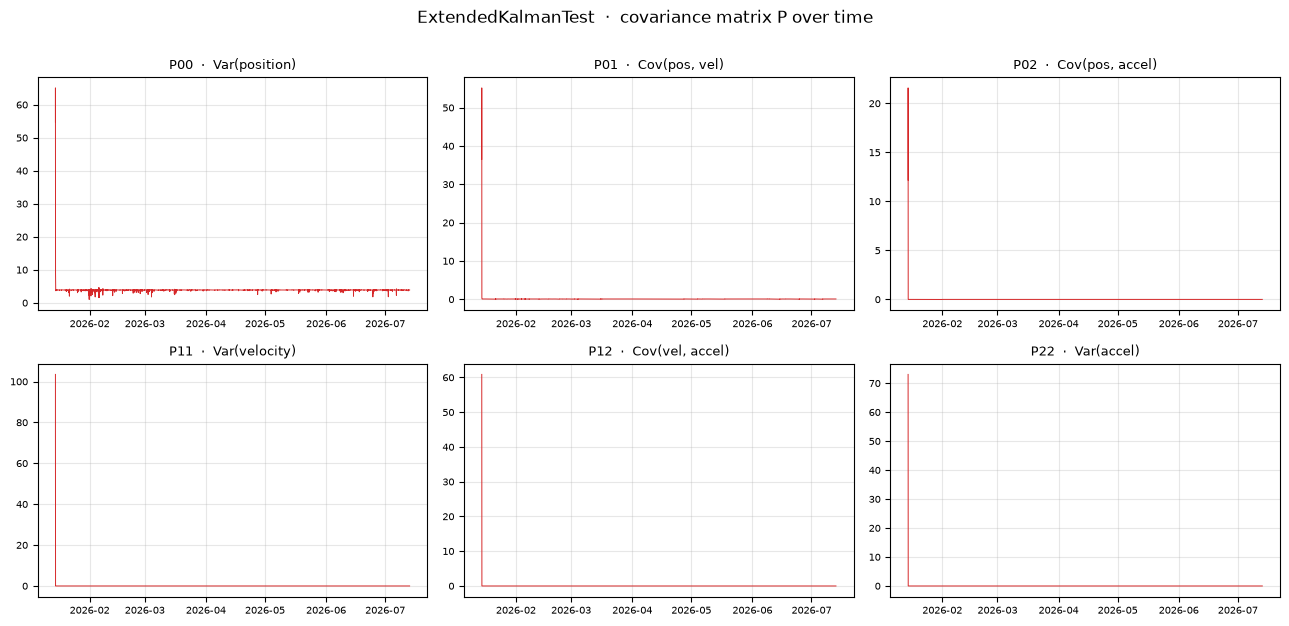

In [56]:
LABELS = {'P00': 'Var(position)', 'P11': 'Var(velocity)', 'P22': 'Var(accel)',
          'P01': 'Cov(pos, vel)', 'P02': 'Cov(pos, accel)', 'P12': 'Cov(vel, accel)'}

def plot_P(res):
    d = res['diag']
    terms = [c for c in d.columns if c.startswith('P')]
    cols = 3
    rows = int(np.ceil(len(terms) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(13, 3.1 * rows))
    axes = np.atleast_1d(axes).reshape(-1)
    for ax, c in zip(axes, terms):
        ax.plot(d.index, d[c], lw=0.7, color='#d62728')
        ax.set_title('%s  ·  %s' % (c, LABELS.get(c, c)), fontsize=9)
        ax.grid(alpha=0.3); ax.tick_params(labelsize=7)
    for ax in axes[len(terms):]:
        ax.axis('off')
    fig.suptitle('%s  ·  covariance matrix P over time' % res['name'], y=1.002, fontsize=12)
    plt.tight_layout(); plt.show()

plot_P(kf)
plot_P(ekf)

### Equity curve

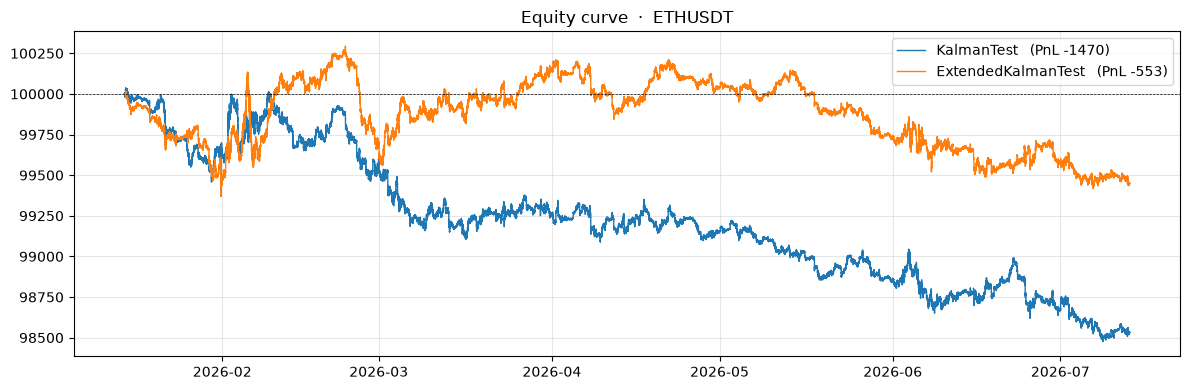

In [57]:
fig, ax = plt.subplots(figsize=(12, 4))
for res in (kf, ekf):
    ax.plot(res['equity'].index, res['equity']['value'], lw=1.0,
            label='%s   (PnL %+.0f)' % (res['name'], res['stats']['pnl']))
ax.axhline(START_CASH, color='k', lw=0.5, ls='--')
ax.set_title('Equity curve  ·  %s' % SYMBOL)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Win rate & PnL

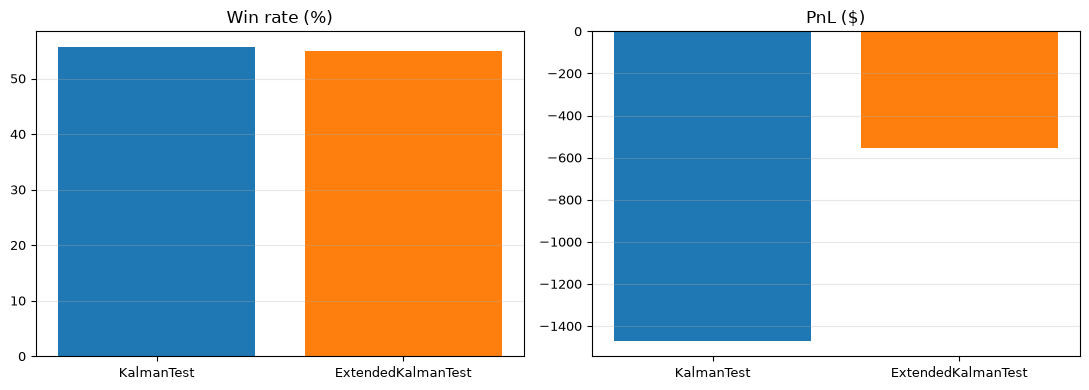

,end_value,pnl,trades,wins,win_rate
KalmanTest,98530.19,-1469.81,587,327,55.71
ExtendedKalmanTest,99446.80,-553.20,429,236,55.01


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = [kf['name'], ekf['name']]
cols = ['#1f77b4', '#ff7f0e']
axes[0].bar(names, [kf['stats']['win_rate'], ekf['stats']['win_rate']], color=cols)
axes[0].set_title('Win rate (%)'); axes[0].grid(alpha=0.3, axis='y')
axes[1].bar(names, [kf['stats']['pnl'], ekf['stats']['pnl']], color=cols)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title('PnL ($)'); axes[1].grid(alpha=0.3, axis='y')
for ax in axes:
    ax.tick_params(labelsize=9)
plt.tight_layout(); plt.show()
summary